# Θέμα 2 — Υβριδικό Σύστημα Συστάσεων
## Notebook 1: Exploratory Data Analysis — MovieLens 1M

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

DATA_PATH = '../data/ml-1m/'

## 1. Φόρτωση Δεδομένων

In [2]:
# Ratings: UserID::MovieID::Rating::Timestamp
ratings = pd.read_csv(
    DATA_PATH + 'ratings.dat',
    sep='::',
    names=['user_id', 'item_id', 'rating', 'timestamp'],
    engine='python',
    encoding='latin-1'
)

# Movies: MovieID::Title::Genres  (genres pipe-separated)
movies = pd.read_csv(
    DATA_PATH + 'movies.dat',
    sep='::',
    names=['item_id', 'title', 'genres'],
    engine='python',
    encoding='latin-1'
)

# Users: UserID::Gender::Age::Occupation::Zip-code
users = pd.read_csv(
    DATA_PATH + 'users.dat',
    sep='::',
    names=['user_id', 'gender', 'age', 'occupation', 'zip_code'],
    engine='python',
    encoding='latin-1'
)

print(f'Ratings: {ratings.shape}')
print(f'Movies:  {movies.shape}')
print(f'Users:   {users.shape}')
print()
print(movies.head(3))

Ratings: (1000209, 4)
Movies:  (3883, 3)
Users:   (6040, 5)

   item_id                    title                        genres
0        1         Toy Story (1995)   Animation|Children's|Comedy
1        2           Jumanji (1995)  Adventure|Children's|Fantasy
2        3  Grumpier Old Men (1995)                Comedy|Romance


## 2. Βασικά Στατιστικά

In [3]:
n_users   = ratings['user_id'].nunique()
n_items   = ratings['item_id'].nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_items)

print(f'Χρήστες:   {n_users:,}')
print(f'Ταινίες:   {n_items:,}')
print(f'Ratings:   {n_ratings:,}')
print(f'Sparsity:  {sparsity:.2%}')
print()
print(ratings['rating'].describe())

Χρήστες:   6,040
Ταινίες:   3,706
Ratings:   1,000,209
Sparsity:  95.53%

count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


## 3. Κατανομή Ratings

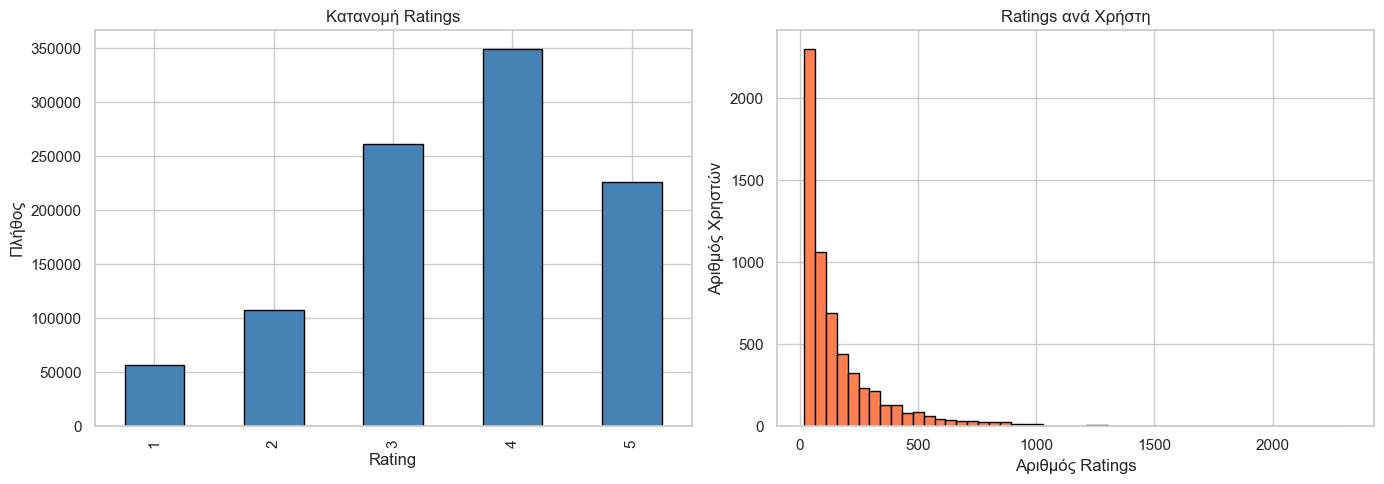

Μέσος αριθμός ratings/χρήστη: 165.6
Min/Max ratings/χρήστη: 20 / 2314


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Κατανομή Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Πλήθος')

ratings_per_user = ratings.groupby('user_id').size()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='black')
axes[1].set_title('Ratings ανά Χρήστη')
axes[1].set_xlabel('Αριθμός Ratings')
axes[1].set_ylabel('Αριθμός Χρηστών')

plt.tight_layout()
plt.savefig('../results/01_rating_distributions.png', dpi=150)
plt.show()

print(f'Μέσος αριθμός ratings/χρήστη: {ratings_per_user.mean():.1f}')
print(f'Min/Max ratings/χρήστη: {ratings_per_user.min()} / {ratings_per_user.max()}')

## 4. Δημοφιλέστερες Ταινίες

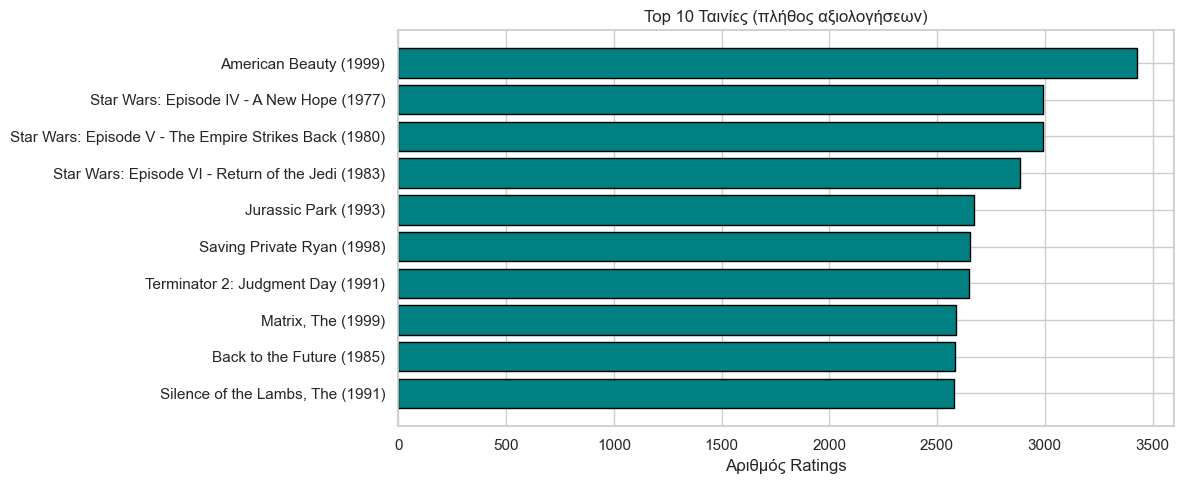

In [5]:
movie_stats = ratings.groupby('item_id').agg(
    count=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index().merge(movies[['item_id','title']], on='item_id')

top10 = movie_stats.nlargest(10, 'count')

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top10['title'], top10['count'], color='teal', edgecolor='black')
ax.set_title('Top 10 Ταινίες (πλήθος αξιολογήσεων)')
ax.set_xlabel('Αριθμός Ratings')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../results/02_top10_movies.png', dpi=150)
plt.show()

## 5. Κατανομή Genres

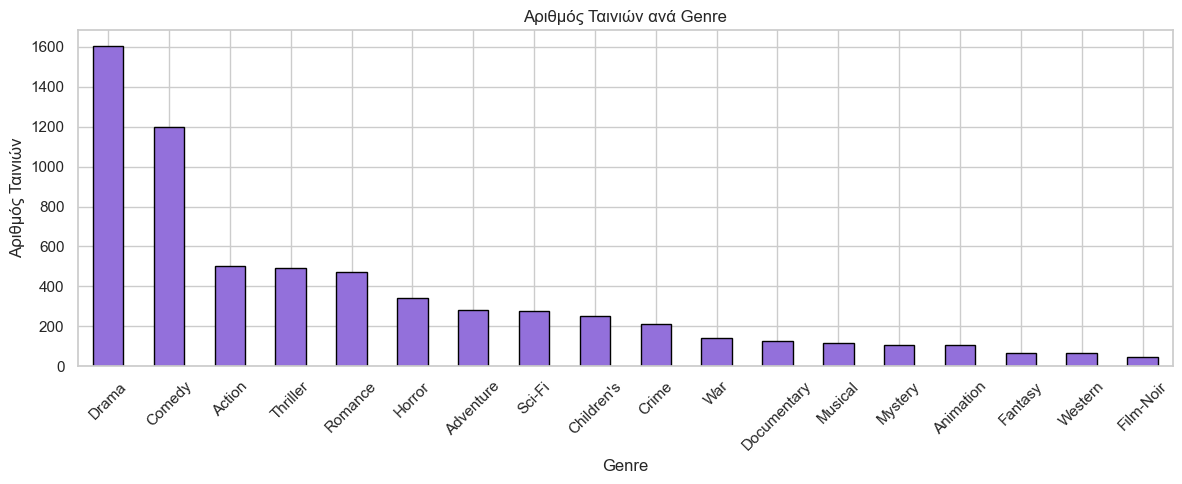

In [6]:
from collections import Counter

all_genres = [g for genres in movies['genres'] for g in genres.split('|')]
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
genre_counts.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Αριθμός Ταινιών ανά Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Αριθμός Ταινιών')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../results/03_genre_distribution.png', dpi=150)
plt.show()

## 6. Δημογραφικά Χρηστών

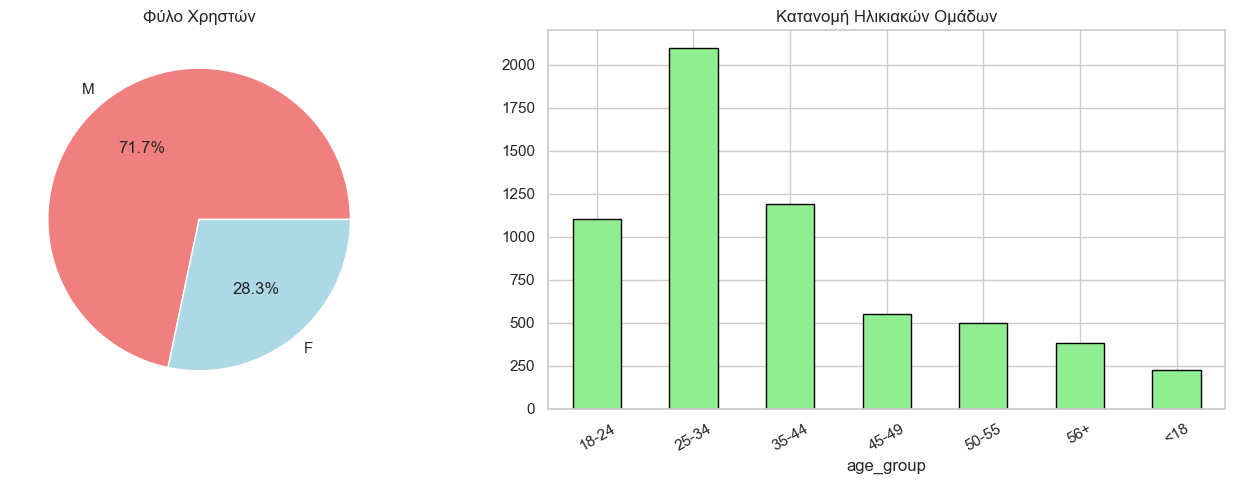

In [7]:
age_map = {1:'<18', 18:'18-24', 25:'25-34', 35:'35-44', 45:'45-49', 50:'50-55', 56:'56+'}
users['age_group'] = users['age'].map(age_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

users['gender'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['lightcoral','lightblue']
)
axes[0].set_title('Φύλο Χρηστών')
axes[0].set_ylabel('')

users['age_group'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='lightgreen', edgecolor='black'
)
axes[1].set_title('Κατανομή Ηλικιακών Ομάδων')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/04_user_demographics.png', dpi=150)
plt.show()

## 7. Train/Test Split (80/20)

In [8]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

print(f'Train: {len(train):,} ratings')
print(f'Test:  {len(test):,} ratings')
print(f'Split: {len(train)/len(ratings):.0%} / {len(test)/len(ratings):.0%}')

train.to_csv('../data/train.csv', index=False)
test.to_csv('../data/test.csv', index=False)
movies.to_csv('../data/movies.csv', index=False)
users.to_csv('../data/users.csv', index=False)

print('\nData αποθηκεύτηκε για τα επόμενα notebooks.')

Train: 800,167 ratings
Test:  200,042 ratings
Split: 80% / 20%



Data αποθηκεύτηκε για τα επόμενα notebooks.


## Συμπεράσματα EDA
- **6.040 χρήστες** αξιολόγησαν **3.706 ταινίες** με συνολικά **1.000.209 ratings**
- **Sparsity ~95.5%**: ο user-item matrix είναι πολύ αραιός — αυτό δικαιολογεί τη χρήση CF και hybrid
- Τα ratings κλίνουν θετικά (μέσος ~3.58) — τάση υψηλής βαθμολόγησης
- Dominant genres: Drama, Comedy, Action — χρήσιμο για το content-based
- 71% άνδρες χρήστες, ηλικιακή ομάδα 25-34 η μεγαλύτερη